# Results Aggregation — Prediction Error vs Baselines (Onsager)

Collects partial results from `pred_err_vs_baselines_onsager`,
averages over seeds, computes SE = std / sqrt(num_seeds), and produces one LaTeX table.

**Setting:** single-index nonlinear response, TwoLayerNN predictor (same architecture for all methods).

**Methods:** DAIF-CKA, AJIVE, MCCA, GCCA, MFA, HPCA

**Table columns:** n values (3000, 3500, 4000)

**Table rows:** methods

**Format:** `mean(se)`. Bold = best (lowest) mean per column.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Latex

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
RES_DIR    = "../Results/pred_err_vs_baselines_onsager"
PLOTS_DIR  = "../Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
OUTPUT_TEX = "results_table_pred_err_vs_baselines_onsager.tex"
OUTPUT_CSV = "output_pred_err_vs_baselines_onsager.csv"

N_VALUES   = [3000, 3500, 4000]
NUM_TRIALS = 50
COL        = "pred_error_nn"

METHOD_LABELS = {
    "daif_cka": "DAIF-CKA",
    "ajive":    "AJIVE",
    "mcca":     "MCCA",
    "gcca":     "GCCA",
    "mfa":      "MFA",
    "hpca":     "HPCA",
}

In [2]:
# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
files = glob.glob(os.path.join(RES_DIR, "partial_result_*.csv"))
if not files:
    raise FileNotFoundError(f"No partial result files found in {RES_DIR}")
print(f"Found {len(files)} files in {RES_DIR}")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total rows: {len(df)}")
df.head()

Found 150 files in ../Results/pred_err_vs_baselines_onsager
Total rows: 900


,n,seed,method,pred_error_nn
0,3000,48,daif_cka,0.032918
1,3000,48,ajive,2.631048
2,3000,48,mcca,2.298336
3,3000,48,gcca,2.510219
4,3000,48,mfa,2.516964


In [3]:
# ---------------------------------------------------------------
# Completeness check
# ---------------------------------------------------------------
print("Completeness check (DAIF-CKA as reference):")
for n in N_VALUES:
    df_n    = df[(df["n"] == n) & (df["method"] == "daif_cka")]
    n_seeds = df_n["seed"].nunique()
    status  = "OK" if n_seeds >= NUM_TRIALS else f"WARNING: only {n_seeds}/{NUM_TRIALS} seeds"
    print(f"  n={n}: {n_seeds} seeds — {status}")

Completeness check (DAIF-CKA as reference):
  n=3000: 50 seeds — OK
  n=3500: 50 seeds — OK
  n=4000: 50 seeds — OK


In [4]:
# ---------------------------------------------------------------
# Aggregate: mean and SE per (method, n)
# summary[method][n] = {'mean': float, 'se': float}
# ---------------------------------------------------------------
summary = {}
for method in METHOD_LABELS:
    summary[method] = {}
    for n in N_VALUES:
        df_s = df[(df["n"] == n) & (df["method"] == method)]
        if len(df_s) == 0 or COL not in df_s.columns:
            summary[method][n] = {"mean": np.nan, "se": np.nan}
            continue
        vals = df_s[COL].dropna()
        summary[method][n] = {
            "mean": float(vals.mean()),
            "se":   float(vals.std() / np.sqrt(len(vals))),
        }

# Sanity print
print(f"{'Method':12s}  " + "  ".join([f'n={n}' for n in N_VALUES]))
print("-" * 55)
for method, label in METHOD_LABELS.items():
    row = "  ".join([f"{summary[method][n]['mean']:.4f}" for n in N_VALUES])
    print(f"{label:12s}  {row}")

Method        n=3000  n=3500  n=4000
-------------------------------------------------------
DAIF-CKA      0.2226  0.2596  0.2393
AJIVE         28.9827  36.0152  33.7574
MCCA          28.9205  35.9590  33.7045
GCCA          28.9238  35.9621  33.7045
MFA           28.9181  35.9590  33.7039
HPCA          28.9253  35.9617  33.7042


In [5]:
# ---------------------------------------------------------------
# Save flat summary CSV
# ---------------------------------------------------------------
rows = []
for method, label in METHOD_LABELS.items():
    for n in N_VALUES:
        v = summary[method][n]
        rows.append({
            "method": label,
            "n":      n,
            "mean":   v["mean"],
            "se":     v["se"],
        })

df_summary = pd.DataFrame(rows)
df_summary.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {OUTPUT_CSV}")
df_summary

Saved output_pred_err_vs_baselines_onsager.csv


,method,n,mean,se
0,DAIF-CKA,3000,0.222595,0.038732
1,DAIF-CKA,3500,0.259575,0.042903
2,DAIF-CKA,4000,0.239309,0.039567
3,AJIVE,3000,28.982724,4.616918
4,AJIVE,3500,36.015203,5.565529
5,AJIVE,4000,33.757401,5.336924
6,MCCA,3000,28.920498,4.618704
7,MCCA,3500,35.958987,5.566670
8,MCCA,4000,33.704528,5.335472
9,GCCA,3000,28.923805,4.619313


In [6]:
# ---------------------------------------------------------------
# Build LaTeX table
#
# Columns: n values
# Rows: methods
# Format: mean(se), bold = lowest mean per column
# ---------------------------------------------------------------

def build_latex_table(summary, method_labels, n_values):
    n_cols      = len(n_values)
    col_spec    = 'l' + 'r' * n_cols
    col_headers = ' & '.join([f'$n = {n}$' for n in n_values])

    # Column minima for bolding (lower pred error = better)
    col_mins = [
        min(
            summary[m][n]['mean']
            for m in method_labels
            if not np.isnan(summary[m][n]['mean'])
        )
        for n in n_values
    ]

    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'\centering')
    lines.append(r'\small')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')
    lines.append(f'Method & {col_headers} \\\\')
    lines.append(r'\midrule')

    for method, label in method_labels.items():
        cells = []
        for col, n in enumerate(n_values):
            mean = summary[method][n]['mean']
            se   = summary[method][n]['se']
            if np.isnan(mean):
                cells.append('---')
                continue
            cell = f'{mean:.3f}({se:.3f})'
            if abs(mean - col_mins[col]) < 1e-9:
                cell = r'\textbf{' + cell + '}'
            cells.append(cell)
        lines.append(f'{label} & ' + ' & '.join(cells) + r' \\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(
        r'\caption{Average prediction error (MSE) across sample sizes '
        r'(mean with standard error in parentheses). '
        r'Single-index nonlinear response; TwoLayerNN predictor for all methods. '
        r'\textbf{DAIF-CKA}: AMP with CKA-based clustering. '
        r'Bold = best mean per column.}'
    )
    lines.append(r'\label{tab:pred_err_vs_baselines_onsager}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


latex_str = build_latex_table(summary, METHOD_LABELS, N_VALUES)
print(latex_str)

\begin{table}[ht]
\centering
\small
\begin{tabular}{lrrr}
\toprule
Method & $n = 3000$ & $n = 3500$ & $n = 4000$ \\
\midrule
DAIF-CKA & \textbf{0.223(0.039)} & \textbf{0.260(0.043)} & \textbf{0.239(0.040)} \\
AJIVE & 28.983(4.617) & 36.015(5.566) & 33.757(5.337) \\
MCCA & 28.920(4.619) & 35.959(5.567) & 33.705(5.335) \\
GCCA & 28.924(4.619) & 35.962(5.566) & 33.705(5.337) \\
MFA & 28.918(4.620) & 35.959(5.566) & 33.704(5.336) \\
HPCA & 28.925(4.619) & 35.962(5.566) & 33.704(5.335) \\
\bottomrule
\end{tabular}
\caption{Average prediction error (MSE) across sample sizes (mean with standard error in parentheses). Single-index nonlinear response; TwoLayerNN predictor for all methods. \textbf{DAIF-CKA}: AMP with CKA-based clustering. Bold = best mean per column.}
\label{tab:pred_err_vs_baselines_onsager}
\end{table}


In [7]:
# ---------------------------------------------------------------
# Render LaTeX table inline
# ---------------------------------------------------------------
display(Latex(latex_str))

<IPython.core.display.Latex object>

In [8]:
# ---------------------------------------------------------------
# Save .tex file
# ---------------------------------------------------------------
with open(OUTPUT_TEX, "w") as f:
    f.write(latex_str)
print(f"Saved {OUTPUT_TEX}")

Saved results_table_pred_err_vs_baselines_onsager.tex


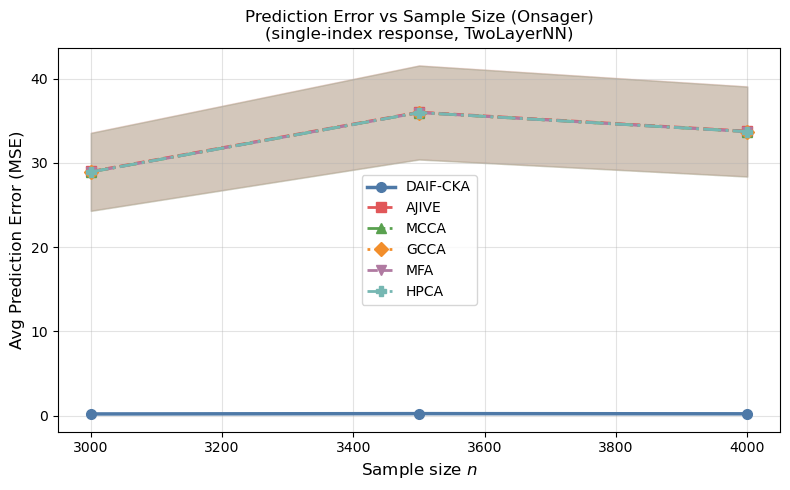

Saved ../Plots/pred_err_vs_baselines_onsager.png


In [9]:
# ---------------------------------------------------------------
# Line plot — mean pred error vs n, one line per method
# ---------------------------------------------------------------
METHOD_STYLES = {
    "daif_cka": {"marker": "o", "linestyle": "-",   "color": "#4E79A7", "lw": 2.5},
    "ajive":    {"marker": "s", "linestyle": "--",  "color": "#E15759", "lw": 2.0},
    "mcca":     {"marker": "^", "linestyle": "-.",  "color": "#59A14F", "lw": 2.0},
    "gcca":     {"marker": "D", "linestyle": ":",   "color": "#F28E2B", "lw": 2.0},
    "mfa":      {"marker": "v", "linestyle": "--",  "color": "#B07AA1", "lw": 2.0},
    "hpca":     {"marker": "P", "linestyle": "-.",  "color": "#76B7B2", "lw": 2.0},
}

fig, ax = plt.subplots(figsize=(8, 5))

for method, label in METHOD_LABELS.items():
    means = np.array([summary[method][n]['mean'] for n in N_VALUES])
    ses   = np.array([summary[method][n]['se']   for n in N_VALUES])
    style = METHOD_STYLES[method]

    ax.plot(
        N_VALUES, means, label=label,
        marker=style['marker'], linestyle=style['linestyle'],
        color=style['color'], linewidth=style['lw'], markersize=7
    )
    ax.fill_between(
        N_VALUES, means - ses, means + ses,
        color=style['color'], alpha=0.12
    )

ax.set_title('Prediction Error vs Sample Size (Onsager)\n(single-index response, TwoLayerNN)', fontsize=12)
ax.set_xlabel('Sample size $n$', fontsize=12)
ax.set_ylabel('Avg Prediction Error (MSE)', fontsize=12)
ax.grid(True, alpha=0.35)
ax.legend(fontsize=10)
fig.tight_layout()

path = os.path.join(PLOTS_DIR, 'pred_err_vs_baselines_onsager.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {path}')